In [6]:
# ==========================================================
# HAWKES PROCESS OF SPREAD WIDENING EVENTS
# OPTIMIZED VERSION (PART 1)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from google.colab import files

# ==========================================================
# STEP 1 : Upload Dataset
# ==========================================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]

depth = pd.read_csv(filename)

# ==========================================================
# STEP 2 : Prepare Data
# ==========================================================

depth["timestamp"] = pd.to_datetime(depth["timestamp"])

depth = depth.sort_values("timestamp").reset_index(drop=True)

# Remove crossed quotes

depth = depth[
    depth["best_ask"] >= depth["best_bid"]
].copy()

depth.reset_index(drop=True, inplace=True)

print("Rows :", len(depth))

# ==========================================================
# STEP 3 : Compute Spread
# ==========================================================

depth["spread"] = (
    depth["best_ask"] -
    depth["best_bid"]
)

depth["spread_change"] = (
    depth["spread"].diff()
)

# ==========================================================
# STEP 4 : Spread Widening Event
# ==========================================================

depth["spread_widening"] = (
    depth["spread_change"] > 0
).astype(int)

events = depth[
    depth["spread_widening"] == 1
].copy()

print("Spread Widening Events :", len(events))

# ==========================================================
# STEP 5 : Event Times
# ==========================================================

event_times = (
    events["timestamp"] -
    depth["timestamp"].iloc[0]
).dt.total_seconds().values

T = event_times[-1]

print("Observation Time :", T)

# ==========================================================
# STEP 6 : Recursive Hawkes Log-Likelihood
# ==========================================================

def negative_log_likelihood(params):

    mu, alpha, beta = params

    if mu <= 0 or alpha <= 0 or beta <= 0:
        return np.inf

    n = len(event_times)

    R = np.zeros(n)

    for i in range(1, n):

        dt = event_times[i] - event_times[i-1]

        R[i] = np.exp(-beta * dt) * (1 + R[i-1])

    intensity = mu + alpha * R

    if np.any(intensity <= 0):
        return np.inf

    loglik = np.sum(np.log(intensity))

    compensator = (
        mu * T +
        (alpha / beta) *
        np.sum(
            1 -
            np.exp(
                -beta *
                (T - event_times)
            )
        )
    )

    return -(loglik - compensator)

# ==========================================================
# STEP 7 : Estimate Parameters
# ==========================================================

initial_guess = [0.10,0.20,1.00]

bounds = [

    (1e-6,None),

    (1e-6,None),

    (1e-6,None)

]

result = minimize(

    negative_log_likelihood,

    initial_guess,

    method="L-BFGS-B",

    bounds=bounds

)

mu_hat, alpha_hat, beta_hat = result.x

print("\nOptimization Finished")

print("----------------------------")

print("Success :", result.success)

print("Message :", result.message)

print()

print("Estimated Parameters")

print("----------------------------")

print("mu =", mu_hat)

print("alpha =", alpha_hat)

print("beta =", beta_hat)

Saving BTCUSDT_Depth_1Hour.csv to BTCUSDT_Depth_1Hour (1).csv
Rows : 31422
Spread Widening Events : 11806
Observation Time : 3599.677

Optimization Finished
----------------------------
Success : True
Message : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Estimated Parameters
----------------------------
mu = 1.4311251878448898
alpha = 0.015479419363012146
beta = 0.027143708941558025


Hawkes intensity computed successfully.
Poisson intensity: 3.279738709889804
             Metric         Value
0  Number of Events  11806.000000
1  Observation Time   3599.677000
2      Estimated mu      1.431125
3   Estimated alpha      0.015479
4    Estimated beta      0.027144
5    Poisson Lambda      3.279739


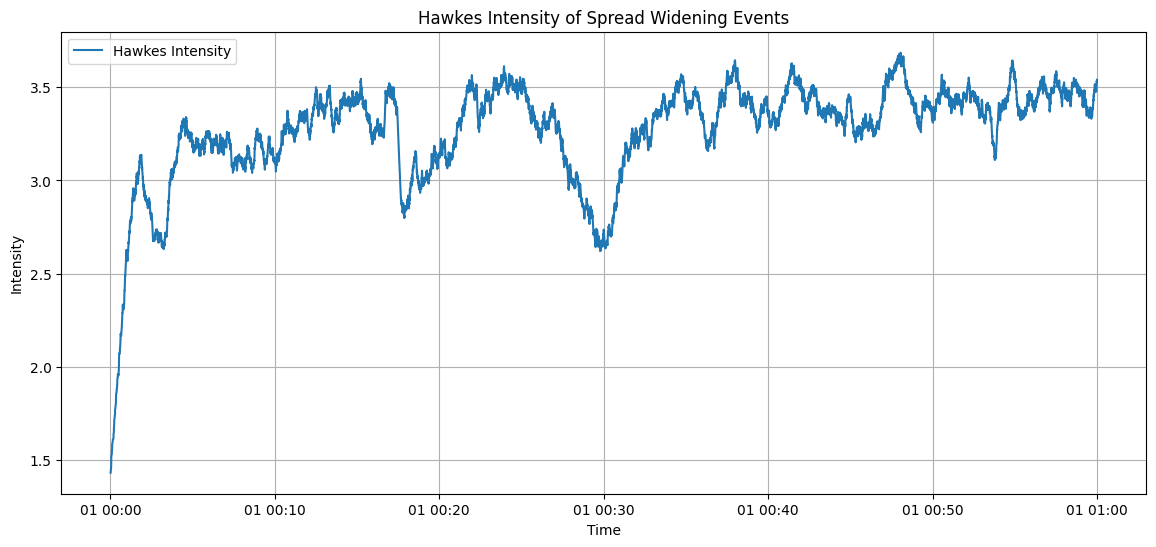

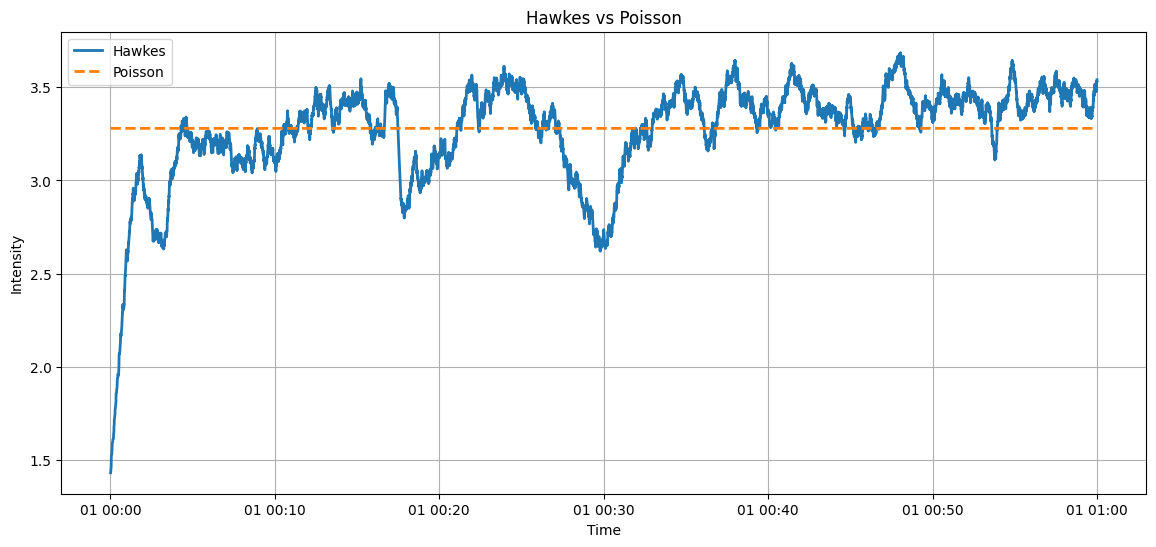

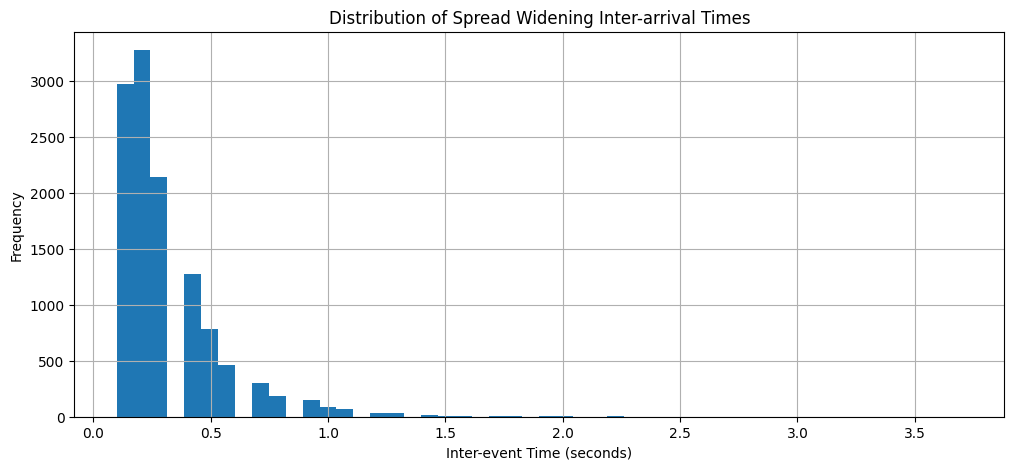


INTERPRETATION
✔ Weak self-excitation.
Spread widening events behave closer to a Poisson process.
✔ Excitation persists for a longer period.

Project completed successfully.


In [7]:
# ==========================================================
# PART 2
# HAWKES INTENSITY
# ==========================================================

n = len(event_times)

R = np.zeros(n)

hawkes_intensity = np.zeros(n)

hawkes_intensity[0] = mu_hat

for i in range(1, n):

    dt = event_times[i] - event_times[i-1]

    R[i] = np.exp(-beta_hat * dt) * (1 + R[i-1])

    hawkes_intensity[i] = mu_hat + alpha_hat * R[i]

events["hawkes_intensity"] = hawkes_intensity

print("Hawkes intensity computed successfully.")

# ==========================================================
# POISSON MODEL
# ==========================================================

poisson_lambda = len(event_times) / T

events["poisson_intensity"] = poisson_lambda

print("Poisson intensity:", poisson_lambda)

# ==========================================================
# SUMMARY TABLE
# ==========================================================

summary = pd.DataFrame({

    "Metric":[

        "Number of Events",

        "Observation Time",

        "Estimated mu",

        "Estimated alpha",

        "Estimated beta",

        "Poisson Lambda"

    ],

    "Value":[

        len(event_times),

        T,

        mu_hat,

        alpha_hat,

        beta_hat,

        poisson_lambda

    ]

})

print(summary)

# ==========================================================
# HAWKES INTENSITY PLOT
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(

    events["timestamp"],

    events["hawkes_intensity"],

    label="Hawkes Intensity",

    linewidth=1.5

)

plt.xlabel("Time")

plt.ylabel("Intensity")

plt.title("Hawkes Intensity of Spread Widening Events")

plt.grid(True)

plt.legend()

plt.show()

# ==========================================================
# HAWKES VS POISSON
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(

    events["timestamp"],

    events["hawkes_intensity"],

    label="Hawkes",

    linewidth=2

)

plt.plot(

    events["timestamp"],

    events["poisson_intensity"],

    "--",

    label="Poisson",

    linewidth=2

)

plt.xlabel("Time")

plt.ylabel("Intensity")

plt.title("Hawkes vs Poisson")

plt.grid(True)

plt.legend()

plt.show()

# ==========================================================
# EVENT DISTRIBUTION
# ==========================================================

plt.figure(figsize=(12,5))

plt.hist(

    np.diff(event_times),

    bins=50

)

plt.xlabel("Inter-event Time (seconds)")

plt.ylabel("Frequency")

plt.title("Distribution of Spread Widening Inter-arrival Times")

plt.grid(True)

plt.show()

# ==========================================================
# INTERPRETATION
# ==========================================================

print("\n==============================")

print("INTERPRETATION")

print("==============================")

if alpha_hat > mu_hat:

    print("✔ Strong self-excitation detected.")

    print("Spread widening events tend to cluster.")

else:

    print("✔ Weak self-excitation.")

    print("Spread widening events behave closer to a Poisson process.")

if beta_hat > 1:

    print("✔ Excitation decays rapidly.")

else:

    print("✔ Excitation persists for a longer period.")

print("\nProject completed successfully.")

In [8]:
# ==========================================================
# MODEL COMPARISON
# Hawkes vs Poisson
# ==========================================================

n = len(event_times)

# ---------- Hawkes Log-Likelihood ----------

R = np.zeros(n)

for i in range(1, n):

    dt = event_times[i] - event_times[i-1]

    R[i] = np.exp(-beta_hat * dt) * (1 + R[i-1])

hawkes_intensity = mu_hat + alpha_hat * R

hawkes_loglik = np.sum(np.log(hawkes_intensity))

hawkes_loglik -= (
    mu_hat*T +
    (alpha_hat/beta_hat) *
    np.sum(
        1 -
        np.exp(
            -beta_hat*(T-event_times)
        )
    )
)

# ---------- Poisson Log-Likelihood ----------

lambda_hat = n/T

poisson_loglik = (
    n*np.log(lambda_hat)
    -
    lambda_hat*T
)

# ---------- AIC ----------

hawkes_aic = 2*3 - 2*hawkes_loglik

poisson_aic = 2*1 - 2*poisson_loglik

# ---------- BIC ----------

hawkes_bic = np.log(n)*3 - 2*hawkes_loglik

poisson_bic = np.log(n)*1 - 2*poisson_loglik

# ---------- Likelihood Ratio ----------

lrt = 2*(hawkes_loglik-poisson_loglik)

comparison = pd.DataFrame({

    "Model":[
        "Poisson",
        "Hawkes"
    ],

    "LogLikelihood":[
        poisson_loglik,
        hawkes_loglik
    ],

    "AIC":[
        poisson_aic,
        hawkes_aic
    ],

    "BIC":[
        poisson_bic,
        hawkes_bic
    ]

})

print("="*60)
print("MODEL COMPARISON")
print("="*60)

print(comparison)

print()

print("Likelihood Ratio Statistic :", lrt)

if hawkes_aic < poisson_aic:

    print("\n✓ Hawkes has lower AIC.")

else:

    print("\n✓ Poisson has lower AIC.")

if hawkes_bic < poisson_bic:

    print("✓ Hawkes has lower BIC.")

else:

    print("✓ Poisson has lower BIC.")

if lrt > 3.84:

    print("✓ Hawkes provides a statistically better fit.")

else:

    print("✓ No strong evidence that Hawkes outperforms Poisson.")

MODEL COMPARISON
     Model  LogLikelihood          AIC          BIC
0  Poisson    2216.738922 -4431.477845 -4424.101481
1   Hawkes    2260.565683 -4515.131366 -4493.002276

Likelihood Ratio Statistic : 87.65352122436525

✓ Hawkes has lower AIC.
✓ Hawkes has lower BIC.
✓ Hawkes provides a statistically better fit.
